In [127]:
!pip install ipympl



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\3nd3r\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
%matplotlib inline
import time
import pylab as pl
from IPython import display
for i in range(10):
    pl.clf()
    pl.plot(pl.randn(100))
    display.display(pl.gcf())
    display.clear_output(wait=True)
    time.sleep(1.0)

KeyboardInterrupt: 

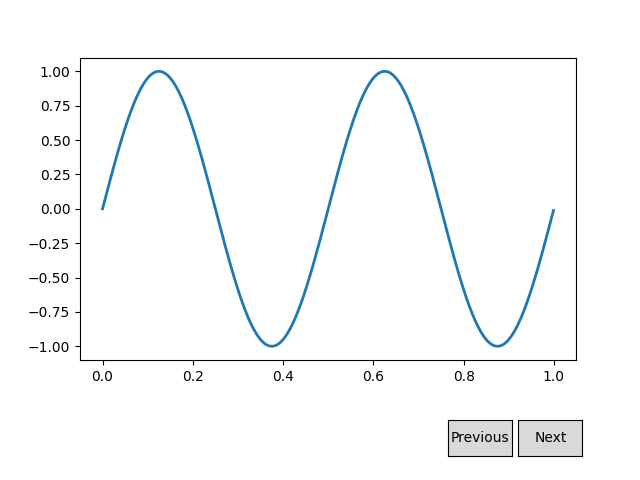

RuntimeError: Another Axes already grabs mouse input

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button

# Backend interactif: requis pour que les widgets Matplotlib captent les clics
%matplotlib widget

freqs = np.arange(2, 20, 3)
t = np.arange(0.0, 1.0, 0.001)

class Index:
    def __init__(self, line, t, freqs, fig):
        self.ind = 0
        self.line = line
        self.t = t
        self.freqs = freqs
        self.fig = fig

    def _set(self):
        f = self.freqs[self.ind % len(self.freqs)]
        ydata = np.sin(2 * np.pi * f * self.t)
        self.line.set_ydata(ydata)
        self.fig.canvas.draw_idle()

    def next(self, event):
        self.ind += 1
        self._set()

    def prev(self, event):
        self.ind -= 1
        self._set()

def myPLOUT():
    fig, ax = plt.subplots()
    fig.subplots_adjust(bottom=0.25)

    line, = ax.plot(t, np.sin(2 * np.pi * freqs[0] * t), lw=2)
    callback = Index(line, t, freqs, fig)

    axprev = fig.add_axes([0.70, 0.05, 0.1, 0.075])
    axnext = fig.add_axes([0.81, 0.05, 0.1, 0.075])

    bnext = Button(axnext, 'Next')
    bnext.on_clicked(callback.next)
    bprev = Button(axprev, 'Previous')
    bprev.on_clicked(callback.prev)

    plt.show()
    # IMPORTANT: retourner les objets pour garder des références (évite GC)
    return fig, callback, bnext, bprev

ui = myPLOUT()

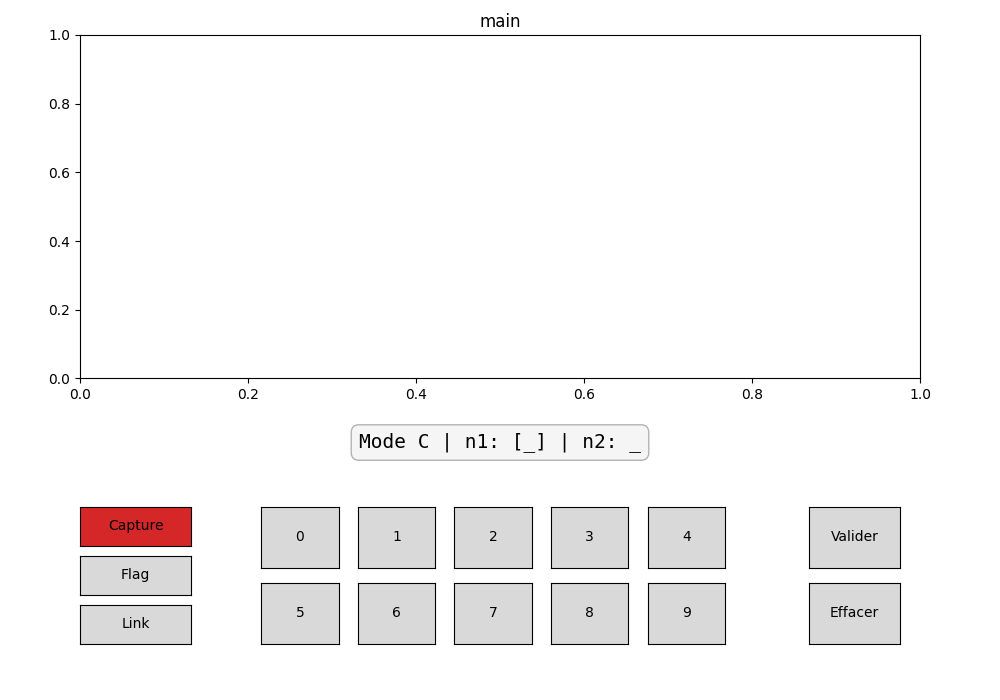

In [32]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Dict, Optional

import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.text import Text
from matplotlib.widgets import Button

DBG = False


@dataclass
class PeritelCallbacks:
    """Callbacks du layout.

    - on_mode_change: appelé quand on change de mode
    - on_digit/on_validate/on_clear: événements bruts UI
    - on_capture/on_flag/on_link: appelés quand une saisie complète est validée
    """

    logger: Callable[[str], None] = print

    def on_mode_change(self, mode: str) -> None:
        self.logger(f"MODE: {mode}")

    def on_digit(self, digit: int) -> None:
        self.logger(f"DIGIT: {digit}")

    def on_validate(self) -> None:
        self.logger("VALIDATE")

    def on_clear(self) -> None:
        self.logger("CLEAR")

    def on_capture(self, first: int, second: int) -> None:
        self.logger(f"CAPTURE({first}, {second})")

    def on_flag(self, value: int) -> None:
        self.logger(f"FLAG({value})")

    def on_link(self, first: int, second: int) -> None:
        self.logger(f"LINK({first}, {second})")


@dataclass
class PeritelUI:
    fig: Figure
    ax_main: Axes
    ax_display: Axes
    display_text: Text
    buttons: Dict[str, Button]
    console: widgets.Output
    selected_left: Optional[str] = None
    first_value: str = ""
    second_value: str = ""
    entering_second: bool = False


def create_layout(callbacks: Optional[PeritelCallbacks] = None) -> PeritelUI:
    """Crée le layout demandé et branche les callbacks métier.

    Layout:
    - En haut: figure principale
    - Au milieu: champ affichant la saisie courante
    - En bas: boutons gauche / clavier numérique / valider-effacer
    """
    console = widgets.Output()
    if DBG:
        display(console)

    def log(msg: str) -> None:
        console.append_stdout(msg + "\n")

    if callbacks is None:
        callbacks = PeritelCallbacks(logger=log)
    else:
        callbacks.logger = log

    fig = plt.figure(figsize=(10, 7))
    fig.subplots_adjust(left=0.08, right=0.92, bottom=0.08, top=0.95)
    gs_outer = fig.add_gridspec(
        nrows=3,
        ncols=1,
        height_ratios=[3.0, 0.55, 1.2],
        hspace=0.18,
    )

    ax_main = fig.add_subplot(gs_outer[0, 0])
    ax_main.set_title("main")

    ax_display = fig.add_subplot(gs_outer[1, 0])
    ax_display.set_axis_off()
    display_text = ax_display.text(
        0.5,
        0.5,
        "",
        ha="center",
        va="center",
        fontsize=14,
        family="monospace",
        bbox={"boxstyle": "round,pad=0.4", "facecolor": "whitesmoke", "edgecolor": "0.7"},
        transform=ax_display.transAxes,
    )

    gs_bottom = gs_outer[2, 0].subgridspec(
        nrows=1,
        ncols=3,
        width_ratios=[1.2, 5.0, 1.35],
        wspace=0.30,
    )

    gs_left = gs_bottom[0, 0].subgridspec(nrows=3, ncols=1, hspace=0.25)
    gs_mid = gs_bottom[0, 1].subgridspec(nrows=2, ncols=5, hspace=0.25, wspace=0.25)
    gs_right_outer = gs_bottom[0, 2].subgridspec(
        nrows=2,
        ncols=3,
        height_ratios=[1, 1],
        width_ratios=[0.16, 1.0, 0.22],
        hspace=0.25,
        wspace=0.0,
    )

    buttons: Dict[str, Button] = {}
    left_modes = [
        ("Capture", "C"),
        ("Flag", "F"),
        ("Link", "L"),
    ]
    left_keys = [f"left_{label}" for label, _ in left_modes]
    left_default_colors: Dict[str, object] = {}
    selected_color = "tab:red"

    state = {
        "mode": "C",
        "first": "",
        "second": "",
        "entering_second": False,
    }

    def set_button_color(button: Button, color: object) -> None:
        button.color = color
        button.hovercolor = color
        button.ax.set_facecolor(color)

    def refresh_display() -> None:
        mode = state["mode"]
        first = state["first"] or "_"
        second = state["second"] or "_"

        if mode == "F":
            content = f"Mode F | value: [{first}]"
        else:
            if state["entering_second"]:
                content = f"Mode {mode} | n1: {state['first'] or '_'} | n2: [{second}]"
            else:
                content = f"Mode {mode} | n1: [{first}] | n2: {second}"

        display_text.set_text(content)
        fig.canvas.draw_idle()

    def reset_inputs() -> None:
        state["first"] = ""
        state["second"] = ""
        state["entering_second"] = False

    def select_left(key: str, mode: str) -> None:
        for current_key in left_keys:
            btn = buttons.get(current_key)
            if btn is None:
                continue
            if current_key == key:
                set_button_color(btn, selected_color)
            else:
                set_button_color(btn, left_default_colors[current_key])

        state["mode"] = mode
        reset_inputs()
        refresh_display()
        callbacks.on_mode_change(mode)

    def append_digit(digit: int) -> None:
        callbacks.on_digit(digit)
        if state["mode"] == "F":
            state["first"] += str(digit)
        elif state["entering_second"]:
            state["second"] += str(digit)
        else:
            state["first"] += str(digit)
        refresh_display()

    def clear_last() -> None:
        callbacks.on_clear()
        if state["mode"] == "F":
            state["first"] = state["first"][:-1]
        elif state["entering_second"]:
            if state["second"]:
                state["second"] = state["second"][:-1]
            else:
                state["entering_second"] = False
                if state["first"]:
                    state["first"] = state["first"][:-1]
        elif state["first"]:
            state["first"] = state["first"][:-1]
        refresh_display()

    def validate_current() -> None:
        callbacks.on_validate()
        mode = state["mode"]

        if mode == "F":
            if not state["first"]:
                return
            callbacks.on_flag(int(state["first"]))
            reset_inputs()
            refresh_display()
            return

        if not state["entering_second"]:
            if not state["first"]:
                return
            state["entering_second"] = True
            refresh_display()
            return

        if not state["second"]:
            return

        first_value = int(state["first"])
        second_value = int(state["second"])

        if mode == "C":
            callbacks.on_capture(first_value, second_value)
        elif mode == "L":
            callbacks.on_link(first_value, second_value)

        reset_inputs()
        refresh_display()

    for idx, (label, mode) in enumerate(left_modes):
        axb = fig.add_subplot(gs_left[idx, 0])
        btn = Button(axb, label)
        key = f"left_{label}"
        left_default_colors[key] = btn.color
        btn.hovercolor = btn.color
        buttons[key] = btn

        def _make_mode_handler(_key: str, _mode: str) -> Callable:
            def _handler(event):
                select_left(_key, _mode)
            return _handler

        btn.on_clicked(_make_mode_handler(key, mode))

    select_left(left_keys[0], "C")

    for k, digit in enumerate(range(10)):
        row = 0 if k < 5 else 1
        col = k % 5
        axb = fig.add_subplot(gs_mid[row, col])
        btn = Button(axb, str(digit))
        btn.on_clicked(lambda event, value=digit: append_digit(value))
        buttons[f"num_{digit}"] = btn

    ax_validate = fig.add_subplot(gs_right_outer[0, 1])
    btn_validate = Button(ax_validate, "Valider")
    btn_validate.on_clicked(lambda event: validate_current())
    buttons["validate"] = btn_validate

    ax_clear = fig.add_subplot(gs_right_outer[1, 1])
    btn_clear = Button(ax_clear, "Effacer")
    btn_clear.on_clicked(lambda event: clear_last())
    buttons["clear"] = btn_clear

    refresh_display()
    plt.show()
    return PeritelUI(
        fig=fig,
        ax_main=ax_main,
        ax_display=ax_display,
        display_text=display_text,
        buttons=buttons,
        console=console,
        selected_left=left_keys[0],
        first_value=state["first"],
        second_value=state["second"],
        entering_second=state["entering_second"],
    )


# Ferme l'ancienne UI avant d'en recréer une pour éviter les conflits de widgets Matplotlib
if "ui" in globals() and getattr(ui, "fig", None) is not None:
    try:
        plt.close(ui.fig)
    except Exception:
        pass

# Exemple d'utilisation
ui = create_layout()